In [1]:
##################################################################`############
#                        BLOCK 1 — IMPORTS AND ENVIRONMENT SETUP             #
##############################################################################

import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix, classification_report
import ipywidgets as widgets
import ipycanvas
from ipycanvas import Canvas
from IPython.display import display, HTML, clear_output
from PIL import Image

# ── Reproducibility ──────────────────────────────────────────────────────────

SEED = 42                          # global seed shared across all blocks
torch.manual_seed(SEED)            # seed PyTorch RNG for weight init & dropout
np.random.seed(SEED)               # seed NumPy RNG for any array-level randomness
random.seed(SEED)                  # seed Python stdlib random for any sampling

# ── Device ───────────────────────────────────────────────────────────────────

DEVICE = torch.device('cpu')       # CPU only — CUDA not available in this env

# ── Matplotlib global config (set once, never touched again) ─────────────────

plt.style.use('dark_background')   # dark canvas for all plots in every block

plt.rcParams.update({
    'figure.figsize':   (12, 5),   # default figure size — wide, readable
    'figure.dpi':       120,       # crisp output inside VS Code Jupyter
    'font.family':      'monospace',  # consistent code-style typography
    'axes.grid':        True,      # grid on by default for readability
    'grid.alpha':       0.3,       # subtle grid — doesn't compete with data
})

# ── System summary ───────────────────────────────────────────────────────────

import sys                         # used only here for version string; not re-exported
print("=" * 52)
print("  MNIST CNN — Environment Summary")
print("=" * 52)
print(f"  Python       : {sys.version.split()[0]}")
print(f"  PyTorch      : {torch.__version__}")
print(f"  Torchvision  : {torchvision.__version__}"  # torchvision imported via transforms/datasets
      if hasattr(torchvision := __import__('torchvision'), '__version__') else
      f"  Torchvision  : (see import)")
print(f"  ipycanvas    : {ipycanvas.__version__}")
print(f"  Device       : {DEVICE}")
print(f"  SEED         : {SEED}")
print("=" * 52)

  MNIST CNN — Environment Summary
  Python       : 3.11.9
  PyTorch      : 2.11.0+cpu
  Torchvision  : 0.26.0+cpu
  ipycanvas    : 0.14.3
  Device       : cpu
  SEED         : 42


In [2]:
##############################################################################
#                     BLOCK 2 — HYPERPARAMETERS AND CONFIGURATION            #
##############################################################################

# All numeric constants for the entire notebook are defined here.
# No other block may define or redefine these. No literal numbers
# corresponding to these constants may appear anywhere in Blocks 3–7.

# ── Data loading ─────────────────────────────────────────────────────────────

BATCH_SIZE      = 64      # balances memory footprint and gradient noise on CPU
TEST_BATCH_SIZE = 1000    # larger is safe for evaluation — no gradients stored

# ── Training schedule ────────────────────────────────────────────────────────

EPOCHS          = 15      # sufficient epochs for 99%+ accuracy with cosine annealing
LR              = 0.001   # Adam's established default for CNN image classification

# ── Regularisation ───────────────────────────────────────────────────────────

DROPOUT_RATE    = 0.5     # standard rate — drops half the FC neurons per forward pass

# ── Model topology ───────────────────────────────────────────────────────────

NUM_CLASSES     = 10      # digits 0 through 9
IMG_SIZE        = 28      # MNIST native image dimension in pixels (height = width)
FC_HIDDEN       = 128     # hidden FC layer width — enough for digit features, no overfit
FLAT_SIZE       = 3136    # flattened feature map after both conv blocks: 64 × 7 × 7

# ── Normalisation statistics ─────────────────────────────────────────────────

MNIST_MEAN      = 0.1307  # precomputed mean of MNIST training pixels scaled to [0, 1]
MNIST_STD       = 0.3081  # precomputed std  of MNIST training pixels scaled to [0, 1]

# ── Pretty-print all constants in an aligned table ───────────────────────────

print("=" * 42)
print("  MNIST CNN — Hyperparameters")
print("=" * 42)

constants = [
    ("BATCH_SIZE",      BATCH_SIZE,      ""),
    ("TEST_BATCH_SIZE", TEST_BATCH_SIZE, ""),
    ("EPOCHS",          EPOCHS,          ""),
    ("LR",              LR,              ""),
    ("DROPOUT_RATE",    DROPOUT_RATE,    ""),
    ("NUM_CLASSES",     NUM_CLASSES,     ""),
    ("IMG_SIZE",        IMG_SIZE,        "px"),
    ("FC_HIDDEN",       FC_HIDDEN,       ""),
    ("FLAT_SIZE",       FLAT_SIZE,       "  # 64 × 7 × 7"),
    ("MNIST_MEAN",      MNIST_MEAN,      ""),
    ("MNIST_STD",       MNIST_STD,       ""),
]

for name, value, note in constants:
    print(f"  {name:<20} {str(value):<10} {note}")

print("=" * 42)

  MNIST CNN — Hyperparameters
  BATCH_SIZE           64         
  TEST_BATCH_SIZE      1000       
  EPOCHS               15         
  LR                   0.001      
  DROPOUT_RATE         0.5        
  NUM_CLASSES          10         
  IMG_SIZE             28         px
  FC_HIDDEN            128        
  FLAT_SIZE            3136         # 64 × 7 × 7
  MNIST_MEAN           0.1307     
  MNIST_STD            0.3081     


  MNIST CNN — Dataset Summary
  Training samples  : 60,000
  Test samples      : 10,000
  Training batches  : 938
  Test batches      : 10
  Image size        : 28 × 28 px
  Classes           : 10  (digits 0–9)


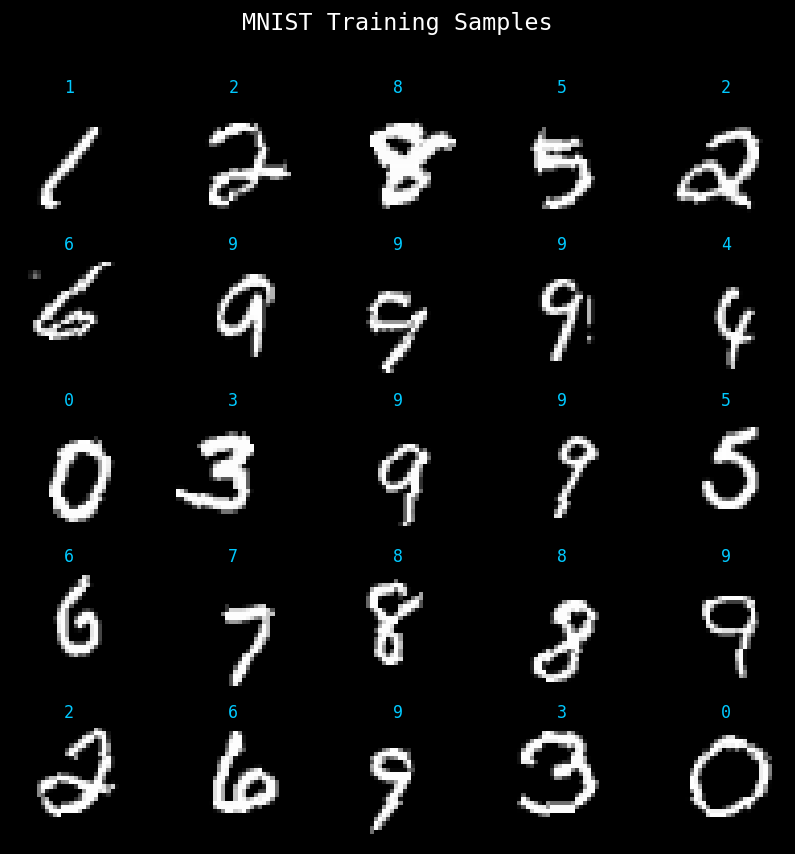

In [3]:
##############################################################################
#                     BLOCK 3 — DATA LOADING AND AUGMENTATION                #
##############################################################################

# ── Transform pipelines ───────────────────────────────────────────────────────

train_transform = transforms.Compose([
    transforms.RandomRotation(10),                          # rotate ±10° to mimic tilted handwriting
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # shift up to 10% in x/y for off-centre digits
    transforms.ToTensor(),                                  # convert PIL image to float tensor in [0, 1]
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),      # standardise to zero mean, unit variance
])

test_transform = transforms.Compose([
    transforms.ToTensor(),                                  # no augmentation at eval time — clean signal only
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),      # same normalisation as training for consistency
])

# ── Dataset download and instantiation ───────────────────────────────────────

data_dir = os.path.join('.', 'data')   # store downloaded files beside the notebook

train_dataset = datasets.MNIST(
    root=data_dir,
    train=True,                        # 60,000 labelled training images
    download=True,                     # fetch from internet if not already on disk
    transform=train_transform,
)

test_dataset = datasets.MNIST(
    root=data_dir,
    train=False,                       # 10,000 labelled test images, never seen during training
    download=True,
    transform=test_transform,
)

# ── DataLoaders ───────────────────────────────────────────────────────────────

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,             # 64 samples per batch — balanced for CPU memory and gradient noise
    shuffle=True,                      # randomise order each epoch to prevent ordering bias
    num_workers=0,                     # RULE: Windows multiprocessing requires num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,        # 1000 samples per batch — safe for eval, no gradients stored
    shuffle=False,                     # fixed order for reproducible evaluation metrics
    num_workers=0,                     # RULE: Windows multiprocessing requires num_workers=0
)

# ── Dataset summary ───────────────────────────────────────────────────────────

print("=" * 42)
print("  MNIST CNN — Dataset Summary")
print("=" * 42)
print(f"  Training samples  : {len(train_dataset):,}")
print(f"  Test samples      : {len(test_dataset):,}")
print(f"  Training batches  : {len(train_loader):,}")
print(f"  Test batches      : {len(test_loader):,}")
print(f"  Image size        : {IMG_SIZE} × {IMG_SIZE} px")
print(f"  Classes           : {NUM_CLASSES}  (digits 0–9)")
print("=" * 42)

# ── Sample image grid ─────────────────────────────────────────────────────────

sample_imgs, sample_labels = next(iter(train_loader))  # grab first training batch

fig, axes = plt.subplots(5, 5, figsize=(7, 7))          # 5×5 grid — 25 sample digits
fig.suptitle('MNIST Training Samples', color='white', fontsize=14, y=1.01)

for idx, ax in enumerate(axes.flat):
    img = sample_imgs[idx].squeeze().cpu().numpy()       # remove channel dim, move to numpy for plotting
    img = img * MNIST_STD + MNIST_MEAN                   # undo normalisation so pixel values look natural
    ax.imshow(img, cmap='gray')                          # grayscale — matches MNIST's single channel
    ax.set_title(str(sample_labels[idx].item()),         # show ground-truth digit label above each image
                 color='#00C9FF', fontsize=10)
    ax.axis('off')                                       # hide axes ticks and spines for clean display

plt.tight_layout()
plt.show()

In [4]:
##############################################################################
#                        BLOCK 4 — MODEL ARCHITECTURE                        #
##############################################################################

# ── Model definition ──────────────────────────────────────────────────────────

class MNISTModel(nn.Module):
    """
    Two-block CNN for MNIST digit classification.
    Conv blocks extract spatial features; FC block classifies.
    Output is raw logits — CrossEntropyLoss applies log-softmax internally.
    """

    def __init__(self):
        super().__init__()

        # Conv Block 1: learns low-level features (edges, curves)
        # Input:  (batch, 1,  28, 28)
        # Output: (batch, 32, 14, 14) after MaxPool
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # preserve spatial size with padding=1
            nn.BatchNorm2d(32),                           # stabilise activations, reduce covariate shift
            nn.ReLU(),                                    # non-linearity — dead-neuron risk lower than LeakyReLU here
            nn.MaxPool2d(2),                              # halve spatial dims: 28×28 → 14×14
        )

        # Conv Block 2: learns higher-level features (digit parts, loops)
        # Input:  (batch, 32, 14, 14)
        # Output: (batch, 64, 7,  7) after MaxPool
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # double filters — richer feature space
            nn.BatchNorm2d(64),                           # BatchNorm before ReLU is standard practice
            nn.ReLU(),
            nn.MaxPool2d(2),                              # halve spatial dims: 14×14 → 7×7
        )

        # Flatten: collapse spatial dims into a single feature vector
        # Input:  (batch, 64, 7, 7)
        # Output: (batch, FLAT_SIZE) = (batch, 3136)
        self.flatten = nn.Flatten()

        # FC block: classify from feature vector
        # Input:  (batch, FLAT_SIZE)
        # Output: (batch, FC_HIDDEN) = (batch, 128)
        self.fc_block = nn.Sequential(
            nn.Linear(FLAT_SIZE, FC_HIDDEN),              # compress 3136-dim vector to 128-dim representation
            nn.ReLU(),                                    # non-linearity before dropout
            nn.Dropout(DROPOUT_RATE),                     # randomly zero 50% of neurons — prevents co-adaptation
        )

        # Output layer: one logit per class, no activation
        # Input:  (batch, FC_HIDDEN) = (batch, 128)
        # Output: (batch, NUM_CLASSES) = (batch, 10)
        self.output_layer = nn.Linear(FC_HIDDEN, NUM_CLASSES)  # raw logits — softmax applied by loss fn

    def forward(self, x):
        x = self.conv_block_1(x)   # spatial feature extraction, stage 1
        x = self.conv_block_2(x)   # spatial feature extraction, stage 2
        x = self.flatten(x)        # reshape (batch, 64, 7, 7) → (batch, 3136)
        x = self.fc_block(x)       # classify: compress and regularise
        x = self.output_layer(x)   # produce one raw logit per digit class
        return x                   # caller applies softmax (inference) or CE loss (training)


# ── Instantiation ─────────────────────────────────────────────────────────────

model = MNISTModel().to(DEVICE)    # move all parameters to CPU (DEVICE = torch.device('cpu'))

# ── Manual layer summary table ────────────────────────────────────────────────
# Built in pure PyTorch — no torchsummary or other external library.
# Verified output shapes are hardcoded as ground truth in the spec;
# parameter counts are computed from actual layer weights.

def count_params(module):
    """Return total number of trainable parameters in a single module."""
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

# Each row: (display label, output shape string, parameter count)
summary_rows = [
    ("Conv2d(1→32) + BN + ReLU + Pool",  f"(batch, 32, 14, 14)", count_params(model.conv_block_1)),
    ("Conv2d(32→64) + BN + ReLU + Pool", f"(batch, 64,  7,  7)", count_params(model.conv_block_2)),
    ("Flatten",                           f"(batch, {FLAT_SIZE})",      0),                          # no parameters
    ("Linear + ReLU + Dropout",           f"(batch, {FC_HIDDEN})",      count_params(model.fc_block)),
    ("Linear (output)",                   f"(batch, {NUM_CLASSES})",     count_params(model.output_layer)),
]

col_layer  = 38
col_shape  = 22
col_params = 12

print("=" * (col_layer + col_shape + col_params + 6))
print("  MNIST CNN — Layer Summary")
print("=" * (col_layer + col_shape + col_params + 6))
print(f"  {'Layer':<{col_layer}} {'Output Shape':<{col_shape}} {'Parameters':>{col_params}}")
print("-" * (col_layer + col_shape + col_params + 6))

for label, shape, params in summary_rows:
    param_str = f"{params:,}" if params > 0 else "—"
    print(f"  {label:<{col_layer}} {shape:<{col_shape}} {param_str:>{col_params}}")

print("-" * (col_layer + col_shape + col_params + 6))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  {'Total trainable parameters':<{col_layer + col_shape}} {total_params:>{col_params},}")
print("=" * (col_layer + col_shape + col_params + 6))

  MNIST CNN — Layer Summary
  Layer                                  Output Shape             Parameters
------------------------------------------------------------------------------
  Conv2d(1→32) + BN + ReLU + Pool        (batch, 32, 14, 14)             384
  Conv2d(32→64) + BN + ReLU + Pool       (batch, 64,  7,  7)          18,624
  Flatten                                (batch, 3136)                     —
  Linear + ReLU + Dropout                (batch, 128)                401,536
  Linear (output)                        (batch, 10)                   1,290
------------------------------------------------------------------------------
  Total trainable parameters                                        421,834


  MNIST CNN — Training
  Epoch  Train Loss  Test Acc %            LR
----------------------------------------------------------------
      1      0.4965       98.48      0.000989
      2      0.2610       98.54      0.000957
      3      0.2095       98.56      0.000905
      4      0.1797       98.95      0.000835
      5      0.1607       99.16      0.000750
      6      0.1447       99.27      0.000655
      7      0.1322       99.38      0.000552
      8      0.1235       99.38      0.000448
      9      0.1092       99.22      0.000345
     10      0.1072       99.38      0.000250
     11      0.0984       99.26      0.000165
     12      0.0944       99.42      0.000095
     13      0.0906       99.45      0.000043
     14      0.0845       99.49      0.000011
     15      0.0825       99.49      0.000000

  Training complete — 13m 30s



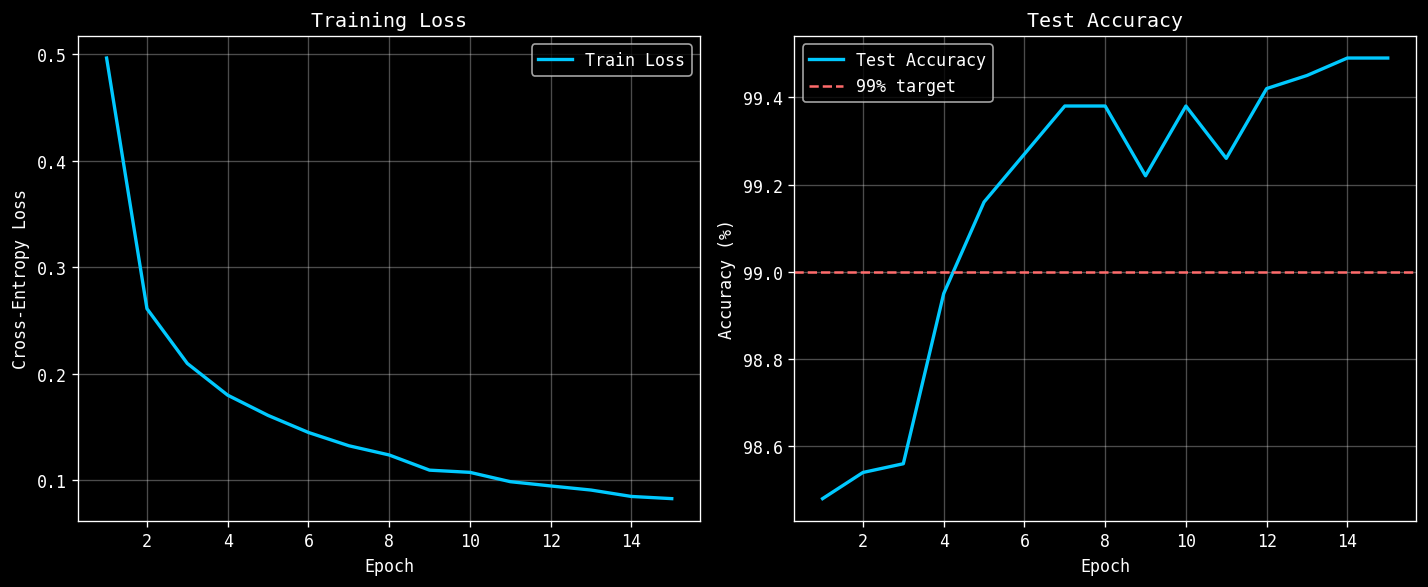

  Weights saved → mnist_cnn.pth


In [5]:
##############################################################################
#                           BLOCK 5 — TRAINING LOOP                          #
##############################################################################

# ── Optimizer and scheduler — local to this block only ───────────────────────

optimizer = optim.Adam(model.parameters(), lr=LR)                        # Adam with spec-defined learning rate
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)  # smooth LR decay over all epochs

# ── Local tracking lists — not shared beyond this block ──────────────────────

train_losses     = []   # average training loss per epoch — for loss curve plot
test_accuracies  = []   # test accuracy per epoch — for accuracy curve plot

# ── Training loop ─────────────────────────────────────────────────────────────

print("=" * 64)
print("  MNIST CNN — Training")
print("=" * 64)
print(f"  {'Epoch':>5}  {'Train Loss':>10}  {'Test Acc %':>10}  {'LR':>12}")
print("-" * 64)

training_start = time.time()   # wall-clock start — used to compute total duration after all epochs

for epoch in range(1, EPOCHS + 1):   # epochs 1 … EPOCHS inclusive

    # ── 1. Training pass ──────────────────────────────────────────────────────

    model.train()                     # enable dropout and BatchNorm training behaviour
    running_loss = 0.0                # accumulate batch losses to compute epoch average

    for batch_data, batch_labels in train_loader:
        batch_data   = batch_data.to(DEVICE)     # move inputs to CPU (DEVICE); no-op here but explicit for portability
        batch_labels = batch_labels.to(DEVICE)   # move labels to same device as model

        optimizer.zero_grad()                                        # clear gradients from previous batch
        output = model(batch_data)                                   # forward pass — raw logits (batch, NUM_CLASSES)
        loss   = nn.CrossEntropyLoss()(output, batch_labels)         # CE applies log-softmax internally — no activation needed
        loss.backward()                                              # backprop: compute gradients for all parameters
        optimizer.step()                                             # update weights in direction of steepest descent

        running_loss += loss.item()   # accumulate scalar loss; .item() detaches from graph

    epoch_loss = running_loss / len(train_loader)   # average loss across all batches this epoch
    train_losses.append(epoch_loss)

    # ── 2. Scheduler step — once per epoch, after all batches ────────────────

    scheduler.step()   # advance cosine annealing — NEVER called inside the batch loop

    # ── 3. Evaluation pass ────────────────────────────────────────────────────

    model.eval()          # disable dropout; BatchNorm uses running stats
    correct = 0
    total   = 0

    with torch.no_grad():                              # no gradient tracking needed for evaluation
        for batch_data, batch_labels in test_loader:
            batch_data   = batch_data.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            output     = model(batch_data)                            # forward pass — raw logits
            predicted  = torch.argmax(output, dim=1)                  # class with highest logit per sample
            correct   += (predicted == batch_labels).sum().item()     # count correct predictions; .item() → Python int
            total     += batch_labels.size(0)                         # accumulate sample count

    accuracy = 100.0 * correct / total   # percentage accuracy over full test set
    test_accuracies.append(accuracy)

    # ── 4. Epoch summary ──────────────────────────────────────────────────────

    current_lr = scheduler.get_last_lr()[0]   # LR after this epoch's scheduler step
    print(f"  {epoch:>5}  {epoch_loss:>10.4f}  {accuracy:>10.2f}  {current_lr:>12.6f}")

print("=" * 64)

# ── Training duration ─────────────────────────────────────────────────────────

elapsed     = time.time() - training_start
elapsed_min = int(elapsed // 60)
elapsed_sec = int(elapsed  % 60)
print(f"\n  Training complete — {elapsed_min}m {elapsed_sec}s\n")

# ── Loss and accuracy curves ──────────────────────────────────────────────────

epoch_axis = list(range(1, EPOCHS + 1))   # x-axis: epoch numbers 1 … EPOCHS

fig, (ax_loss, ax_acc) = plt.subplots(1, 2)   # figsize inherited from Block 1 rcParams (12, 5)

# Training loss curve
ax_loss.plot(epoch_axis, train_losses, color='#00C9FF', linewidth=2, label='Train Loss')
ax_loss.set_title('Training Loss',      color='white')
ax_loss.set_xlabel('Epoch',             color='white')
ax_loss.set_ylabel('Cross-Entropy Loss',color='white')
ax_loss.legend()

# Test accuracy curve with 99% reference line
ax_acc.plot(epoch_axis, test_accuracies, color='#00C9FF', linewidth=2, label='Test Accuracy')
ax_acc.axhline(y=99, color='#FF6B6B', linestyle='--', linewidth=1.5, label='99% target')  # target reference
ax_acc.set_title('Test Accuracy',       color='white')
ax_acc.set_xlabel('Epoch',             color='white')
ax_acc.set_ylabel('Accuracy (%)',       color='white')
ax_acc.legend()

plt.tight_layout()
plt.show()

# ── Finalise model and save weights ──────────────────────────────────────────

model.eval()                                      # ensure eval mode before saving — no active dropout at inference
torch.save(model.state_dict(), 'mnist_cnn.pth')  # save only weights, not full model — loaded by Blocks 6 and 7
print("  Weights saved → mnist_cnn.pth")

  MNIST CNN — Final Evaluation
  Test accuracy : 99.4900%


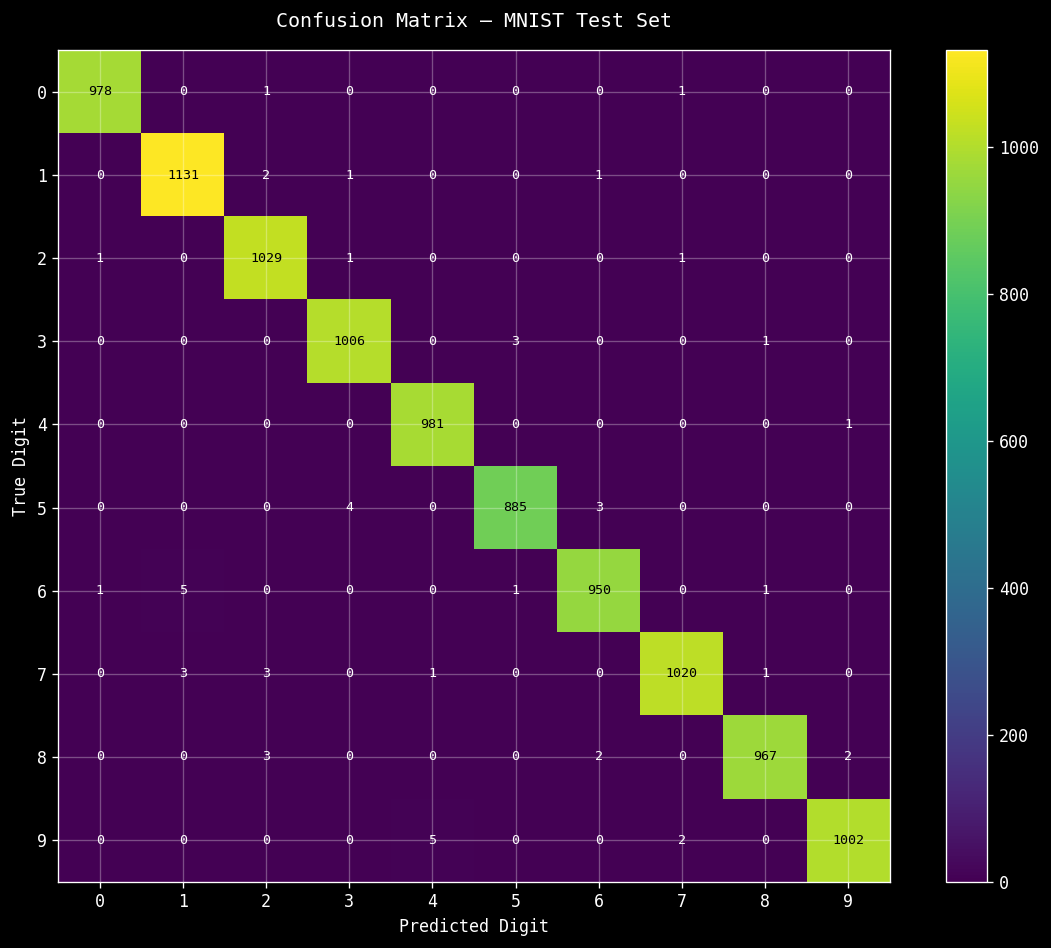


  Per-Class Accuracy (weakest last)
  Digit   Correct    Total   Accuracy
------------------------------------------
      6       950      958     99.16%
      5       885      892     99.22%
      7      1020     1028     99.22%
      8       967      974     99.28%
      9      1002     1009     99.31%
      3      1006     1010     99.60%
      1      1131     1135     99.65%
      2      1029     1032     99.71%
      0       978      980     99.80%
      4       981      982     99.90%

  Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99

In [6]:
##############################################################################
#                     BLOCK 6 — EVALUATION AND CONFUSION MATRIX              #
##############################################################################

# ── Reload weights into existing model instance ───────────────────────────────

model.load_state_dict(torch.load('mnist_cnn.pth', map_location='cpu'))  # RULE: map_location='cpu' mandatory
model.eval()   # disable dropout; BatchNorm uses running statistics

# ── Full inference pass over test set ────────────────────────────────────────

all_predictions = []   # accumulate per-batch predictions as numpy arrays
all_labels      = []   # accumulate per-batch ground-truth labels as numpy arrays

with torch.no_grad():                               # no gradient tracking needed for evaluation
    for batch_data, batch_labels in test_loader:
        batch_data   = batch_data.to(DEVICE)        # move inputs to CPU device
        batch_labels = batch_labels.to(DEVICE)      # move labels to same device

        output    = model(batch_data)               # forward pass — raw logits (batch, NUM_CLASSES)
        predicted = torch.argmax(output, dim=1)     # index of highest logit = predicted class

        all_predictions.append(predicted.cpu().numpy())    # RULE: always .cpu().numpy() even on CPU
        all_labels.append(batch_labels.cpu().numpy())      # detach and convert each batch immediately

# Concatenate list of per-batch arrays into single flat arrays
all_predictions = np.concatenate(all_predictions)   # shape: (10000,)
all_labels      = np.concatenate(all_labels)         # shape: (10000,)

# ── Final accuracy ────────────────────────────────────────────────────────────

final_accuracy = 100.0 * (all_predictions == all_labels).sum() / len(all_labels)
print("=" * 42)
print("  MNIST CNN — Final Evaluation")
print("=" * 42)
print(f"  Test accuracy : {final_accuracy:.4f}%")
print("=" * 42)

# ── Confusion matrix ──────────────────────────────────────────────────────────

cm = confusion_matrix(all_labels, all_predictions)   # called directly by imported name — never sklearn.metrics.confusion_matrix

fig, ax = plt.subplots(figsize=(10, 8))              # square-ish figure — 10×10 matrix needs room

im = ax.imshow(cm, cmap='viridis')                   # viridis: perceptually uniform, dark-background friendly
fig.colorbar(im, ax=ax)                              # legend showing count scale

# Axis tick labels: digits 0 through 9
digit_labels = [str(i) for i in range(NUM_CLASSES)]  # uses NUM_CLASSES — no literal 10
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(digit_labels)
ax.set_yticklabels(digit_labels)

ax.set_title('Confusion Matrix — MNIST Test Set', color='white', pad=14)
ax.set_xlabel('Predicted Digit',                  color='white')
ax.set_ylabel('True Digit',                       color='white')

# Annotate every cell with its integer count
cm_max = cm.max()                                    # used to determine text contrast threshold

for row in range(NUM_CLASSES):
    for col in range(NUM_CLASSES):
        value     = cm[row, col]
        # white text on dark cells, black text on bright cells — ensures readability across the colormap
        txt_color = 'white' if value < cm_max / 2 else 'black'
        ax.text(col, row, str(value),               # note: imshow indexes (col, row) for x, y
                ha='center', va='center',
                color=txt_color, fontsize=8)

plt.tight_layout()
plt.show()

# ── Per-class accuracy table ──────────────────────────────────────────────────

row_sums       = cm.sum(axis=1)                      # total true samples per digit class
diagonal       = cm.diagonal()                       # correctly classified count per class
class_accuracy = diagonal / row_sums                 # fraction correct per class

# Build rows and sort ascending by accuracy so weakest digit appears last
class_rows = [
    (digit, int(diagonal[digit]), int(row_sums[digit]), class_accuracy[digit] * 100)
    for digit in range(NUM_CLASSES)
]
class_rows.sort(key=lambda r: r[3])                  # ascending accuracy — weakest digit last

print("\n" + "=" * 42)
print("  Per-Class Accuracy (weakest last)")
print("=" * 42)
print(f"  {'Digit':>5}  {'Correct':>8}  {'Total':>7}  {'Accuracy':>9}")
print("-" * 42)
for digit, correct, total, acc in class_rows:
    print(f"  {digit:>5}  {correct:>8}  {total:>7}  {acc:>8.2f}%")
print("=" * 42)

# ── Classification report ─────────────────────────────────────────────────────

print("\n  Classification Report\n")
# called directly by imported name — never sklearn.metrics.classification_report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=[str(i) for i in range(NUM_CLASSES)],   # uses NUM_CLASSES — no literal 10
))

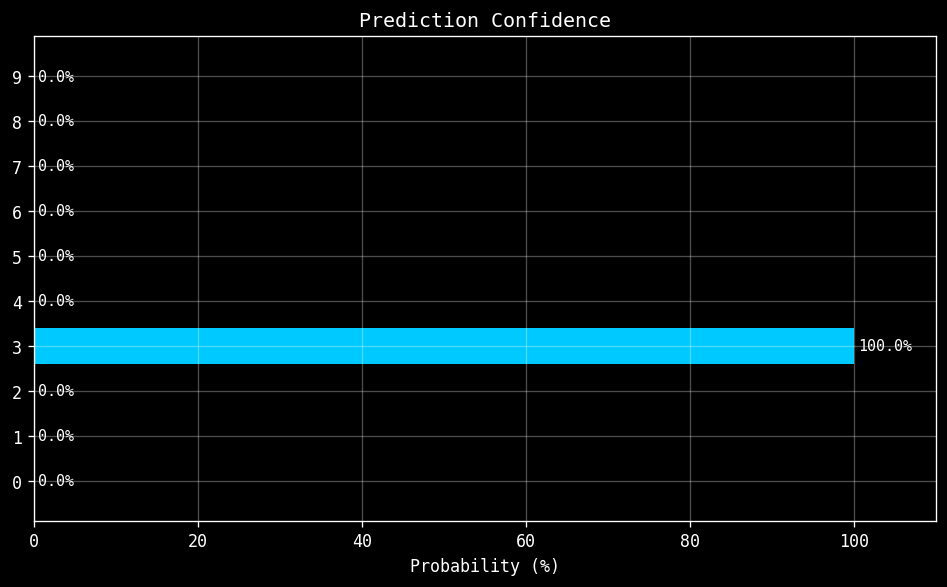

In [7]:
##############################################################################
#                     BLOCK 7 — DRAWING CANVAS AND LIVE PREDICTION           #
##############################################################################

# ── Reload weights into existing model instance ───────────────────────────────

model.load_state_dict(torch.load('mnist_cnn.pth', map_location='cpu'))  # RULE: map_location='cpu' mandatory
model.eval()   # disable dropout; BatchNorm uses running statistics

# ── Canvas and mirror array setup ────────────────────────────────────────────

canvas      = Canvas(width=280, height=280)          # drawing surface — 10× upscale of IMG_SIZE (28px)
canvas_data = np.zeros((280, 280), dtype=np.float32) # Python-side mirror array — single source of truth for prediction
                                                     # ipycanvas pixel extraction is async; cannot be used in sync callback
is_drawing  = [False]                                # mutable list so inner functions can mutate it via closure

canvas.fill_style = 'black'                          # initialise background to black — matches MNIST digit style
canvas.fill_rect(0, 0, 280, 280)                     # flood-fill entire canvas before any drawing

# ── Drawing helpers ───────────────────────────────────────────────────────────

def _paint(x, y):
    """Paint one brush stamp at (x, y) on canvas and mirror array."""
    canvas.fill_style = 'white'
    canvas.fill_circle(x, y, 6)                      # smooth circular brush for natural drawing feel

    x_int, y_int = int(x), int(y)                    # cast to int — array indices must be integers
    for row in range(max(0, y_int - 6), min(280, y_int + 6)):   # clamp to valid array bounds
        for col in range(max(0, x_int - 6), min(280, x_int + 6)):
            canvas_data[row, col] = 255.0             # mark pixel as fully white in mirror array

# ── Mouse event callbacks ─────────────────────────────────────────────────────

def on_mouse_down(x, y):
    """Begin a stroke when the mouse button is pressed."""
    is_drawing[0] = True                             # set drawing flag — move events now paint
    _paint(x, y)                                     # paint the initial press point immediately

def on_mouse_move(x, y):
    """Continue stroke while mouse button is held."""
    if is_drawing[0]:                                # only paint when button is down — simulates drag
        _paint(x, y)

def on_mouse_up(x, y):
    """End stroke when mouse button is released."""
    is_drawing[0] = False                            # clear flag — move events no longer paint

def on_mouse_out(x, y):
    """End stroke if cursor leaves canvas — prevents stuck drawing state."""
    is_drawing[0] = False                            # same as mouse_up: reset flag on canvas exit

canvas.on_mouse_down(on_mouse_down)                  # register all four handlers with ipycanvas
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)
canvas.on_mouse_out(on_mouse_out)


def on_clear(b):
    """Reset canvas visually and wipe the mirror array."""
    canvas.clear()                                   # remove all drawn content from canvas surface
    canvas.fill_style = 'black'                      # restore black background
    canvas.fill_rect(0, 0, 280, 280)                 # flood-fill to match initial state
    canvas_data[:] = 0.0                             # zero every element in mirror array — in-place, preserves reference


def on_predict(b):
    """Read canvas_data, preprocess, run inference, display result and bar chart."""

    # Step 1 — Guard: reject empty canvas before any processing
    if canvas_data.max() == 0.0:                     # all zeros means nothing has been drawn
        display(HTML('<h3 style="color:#FF6B6B">Please draw a digit first</h3>'))
        return

    # Step 2 — Convert mirror array to PIL Image
    img = Image.fromarray(canvas_data.astype(np.uint8), mode='L')   # uint8 required by PIL; mode L = grayscale

    # Step 3 — Resize to model input dimensions
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS) # RULE: Image.Resampling.LANCZOS
                                                                      # RULE: IMG_SIZE constant — not literal 28

    # Step 4 — Convert to normalised float array
    img_array = np.array(img, dtype=np.float32) / 255.0  # scale pixel values from [0, 255] to [0.0, 1.0]

    # Step 5 — Add batch and channel dimensions
    tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0)  # (28,28) → (1,1,28,28): batch=1, channel=1

    # Step 6 — Normalise with MNIST statistics
    tensor = (tensor - MNIST_MEAN) / MNIST_STD       # RULE: use named constants — not literals 0.1307 / 0.3081

    # Step 7 — Inference
    with torch.no_grad():                             # no gradient tracking at inference time
        output = model(tensor.to(DEVICE))             # forward pass — raw logits (1, NUM_CLASSES)

    # Step 8 — Convert logits to probabilities
    probs = F.softmax(output, dim=1).squeeze().cpu().numpy()  # RULE: dim=1 mandatory; RULE: .cpu().numpy()
                                                              # squeeze: (1, NUM_CLASSES) → (NUM_CLASSES,)

    # Step 9 — Extract prediction and confidence
    predicted  = int(np.argmax(probs))               # index of highest probability = predicted digit
    confidence = float(probs[predicted]) * 100        # convert fraction to percentage

    # Step 10 — Redisplay UI then show result header
    clear_output(wait=True)                           # wipe previous output cleanly before redrawing
    display(ui)                                       # redisplay canvas + buttons (ui defined below as closure var)
    display(HTML(
        f'<h2 style="color:#00C9FF">Predicted: {predicted}</h2>'
        f'<h3 style="color:#ffffff">Confidence: {confidence:.1f}%</h3>'
    ))

    # Step 11 — Probability bar chart across all classes
    digit_labels = [str(i) for i in range(NUM_CLASSES)]  # y-axis labels: '0' through '9'
    bar_colors   = [
        '#00C9FF' if i == predicted else '#444444'    # highlight predicted digit; mute all others
        for i in range(NUM_CLASSES)
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.barh(digit_labels, probs * 100, color=bar_colors)  # horizontal bars: digits on y-axis, % on x-axis

    for bar, prob in zip(bars, probs):
        ax.text(
            bar.get_width() + 0.5,                   # position just beyond bar tip
            bar.get_y() + bar.get_height() / 2,      # vertically centred on bar
            f'{prob * 100:.1f}%',
            va='center', color='white', fontsize=9,
        )

    ax.set_title('Prediction Confidence', color='white')
    ax.set_xlabel('Probability (%)',       color='white')
    ax.set_xlim(0, 110)                              # extra headroom so value labels don't clip

    plt.tight_layout()
    display(fig)
    plt.close(fig)                                    # release figure memory immediately after display


# ── Buttons ───────────────────────────────────────────────────────────────────

predict_btn = widgets.Button(description='Predict', button_style='success')
clear_btn   = widgets.Button(description='Clear',   button_style='danger')

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)

# ── Layout and display — order is mandatory ───────────────────────────────────

button_row = widgets.HBox([predict_btn, clear_btn])  # buttons side by side below canvas
ui         = widgets.VBox([canvas, button_row])       # canvas above buttons — ui referenced inside on_predict closure

display(ui)